---
<a id='top'></a>
# Analysis

The documentation below describes how to use the code base to analyze output from the U-net model. 
This guide assumes you have read through the {doc}`Installation <installation>`, {doc}`Data <data>`, and {doc}`Running the model <run_model>` pages and have model output available for analysis on Animus.
<!-- Note: for linking between documents, use the `doc` role defined in the [Sphinx documentation](https://docs.readthedocs.com/platform/stable/guides/cross-referencing-with-sphinx.html#the-doc-role). 
TLDR: Create a link to a different document by typing `{doc}`, followed by the name of the file surrounded by backticks, excluding the extension. If you would like to change the rendered text of the link, surround the desired link text in backticks, then add the name of the file in angle brackets, in the format: "{doc}`Click here <filename>`".  -->

## Table of Contents

- [Before you start](#before_you_start)
- [Exploring a dataset](#exploring_a_dataset)
    - [Inspecting with Jupyter Notebook output](#jupyter_inspect)
    - [Inspecting with map plots](#map_inspect)
    - [Inspecting `uarray` objects](#uarray_inspect)
- [Comparing inputs](#compare_inputs)
- [Plotting results](#plotting_results)

---
<a id='before_you_start'></a>
[back to top](#top)

## Before you start

A good thing to do before starting is to check the version of the `unox` package you are using and the current working directory. 
The first time you run a cell in a notebook in VSCodium, it will ask you to select an environment to use. 
Be sure to select `uplt`, or whatever you named the environment during {doc}`installation <installation>`.

In [1]:
import unox
print(unox.__version__)

0.1.1


In [2]:
import os
os.getcwd()

'/home/mschee/unox/docs'

The current working directory for this example guide is within the `docs/` directory.
For this reason, most of the file paths below are prepended by `../` to indicate that you must first go up one directory level, then search for the file. 

When doing analysis, I generally use a Jupyter Notebook.
The notebook named `plot_tests.ipynb` is deliberately left blank as a place to test things out.
I encourage you to follow along in that notebook as you go through this guide, noting any differences you need to keep track of based on the working directory and trying out different combinations that aren't explicitly explored here.

---
<a id='exploring_a_dataset'></a>
[back to top](#top)
## Exploring a dataset

The code base contains a number of methods of exploring a dataset that is in a netCDF file.
A number of sample datasets are listed below. 
Pick one to explore with this section.

In [4]:
# ERA5 U-wind component for 2019
sample_dataset = '../datafiles/sample_data/2019u10.nc'
# `t106` NOx emissions over North America for 2019
# sample_dataset = '../datafiles/sample_data/nox_2019_t106_US.nc'
# TROPESS reanalysis NOx for 2021
# sample_dataset = '../datafiles/sample_data/TROPESS_reanalysis_mon_emi_nox_anth_2021.nc'
# An example input netCDF
sample_dataset = '../inputfiles/no2_2019/no2_2019.nc'
# An example output netCDF
# sample_dataset = '../HPC_runs/write_docs1/predictions.nc'

<a id='jupyter_inspect'></a>
[back to top](#top)
### Inspecting with Jupyter Notebook output

The simplest way to see what a dataset contains is to load it with `xarray`:

In [5]:
from xarray import open_dataset 

open_dataset(sample_dataset)

<xarray.Dataset> Size: 254MB
Dimensions:     (time: 364, lat: 56, lon: 120, var: 1)
Coordinates:
  * lat         (lat) float32 224B 11.78 12.9 14.02 15.14 ... 71.21 72.34 73.46
  * lon         (lon) float32 480B -174.4 -173.2 -172.1 ... -42.75 -41.62 -40.5
  * time        (time) object 3kB 2019-01-02 00:00:00 ... 2019-12-31 00:00:00
Dimensions without coordinates: var
Data variables: (12/13)
    nox         (time, lat, lon, var) float64 20MB ...
    no2         (time, lat, lon) float64 20MB ...
    no2_s2      (time, lat, lon) float64 20MB ...
    no2_tm1     (time, lat, lon) float64 20MB ...
    no2_s2_tm1  (time, lat, lon) float64 20MB ...
    u10         (time, lat, lon) float64 20MB ...
    ...          ...
    blh         (time, lat, lon) float64 20MB ...
    sp          (time, lat, lon) float64 20MB ...
    skt         (time, lat, lon) float64 20MB ...
    t2m         (time, lat, lon) float64 20MB ...
    ssrd        (time, lat, lon) float64 20MB ...
    lsm         (time, lat, lon) float64 20MB ...
Attributes: (12/17)
    description:        Input data for the Unet model. Data for each year is ...
    y_var:              nox
    emiss_dir:          /data/high_res/emacdonald/unet/datafiles/t106
    emiss_pre:          nox_
    emiss_post:         _t106_US.nc
    nan_fill:           0
    ...                 ...
    x2_vars:            ['no2_s2', 'no2_s2_tm1', 'u10', 'v10', 'blh', 'sp', '...
    data_dir:           /data/high_res
    chemra_path:        emacdonald/unet/datafiles/TROPESS/TROPESS_reanalysis_...
    insitu_path:        US_EPA/NO2/daily_NO2/daily_42602_
    era5_path:          ERA5concatenated
    stages:             [1 2]

The result is an interactive output window which can be extremely handy to quickly verify certain aspects of a dataset. The sections that appear will depend on what dataset you are looking at, but generally include:
- Dimensions
    - The names and lengths of the dimensions of the dataset.
- Coordinates
    - The arrays which define the values of the dimensional axes.
- Data variables
    - The arrays of values for each data variable.
- Indexes
    - The coordinate arrays which are used to index data locations in the dataset.
- Attributes
    - Metadata about the dataset (i.e., data sources, creation date, attributions, formatting notes, etc.)

The dimensions, coordinates, and indexes for a dataset are interrelated. 
While the specific distinctions between them do matter in particular cases, generally they define the axes across which the data is stored. 
See the `xarray` [Terminology](https://docs.xarray.dev/en/latest/user-guide/terminology.html) page for details. 

In the output above, there are several interactive features:
- Arrows next to sections (far left)
    - Click these to expand or collapse each section.
- Metadata (symbol that looks like a file, far right)
    - Click these to see a particular aspect's metadata (i.e., long name, units, etc.).
- Data preview (symbol that looks like a cylinder, far right)
    - Click these to see  a preview of the data stored in a particular aspect.


<a id='map_inspect'></a>
[back to top](#top)
### Inspecting with map plots

While viewing the interactive text-based output above can give you a quick overview of what is in a dataset, it is often helpful to see plots of the data. 
NASA provides an application called [Panoply](https://www.giss.nasa.gov/tools/panoply/) which is a powerful tool for visualizing netCDF files containing geospatial data.
If you are familiar with Panoply, please feel free to use it.
Otherwise, the code base of `unox` includes several plotting functions which can quickly give an idea of what the dataset contains.

The cell below shows the use of a function to simply plot a box on a world map showing the maximum and minimum extents of the dataset in latitude and longitude. 

/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


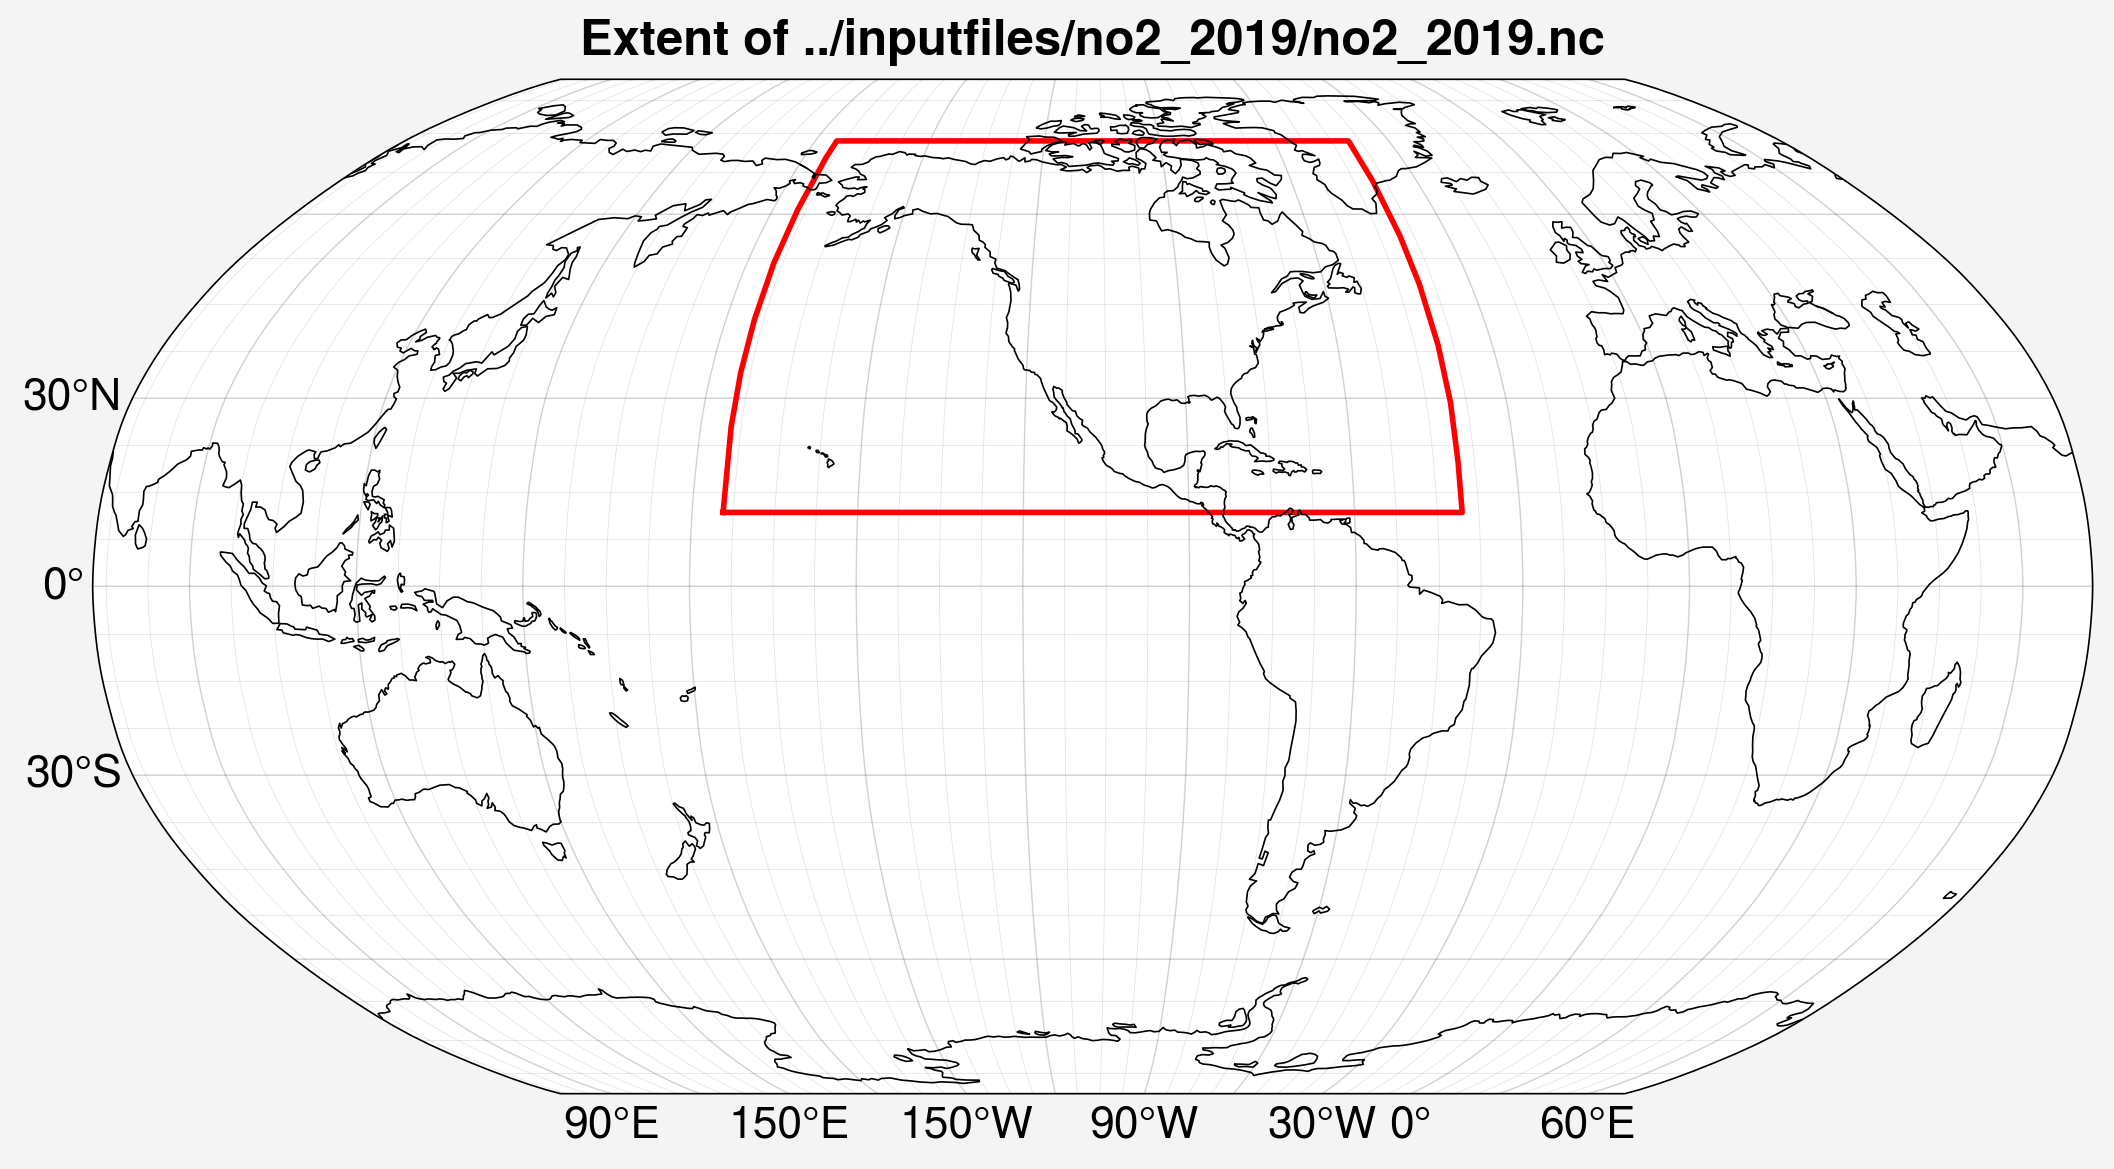

In [6]:
from unox.plotting import plot_extent 

extent_plot = plot_extent(sample_dataset)

The next cell shows a function which plots a checkered grid on a map to show the rough resolution of the dataset.
You can pass an optional keyword argument `padding` to change how much space is added around the extent of the dataset.
 
Note that this function is not currently optimized for datasets that cover the entire globe.

/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


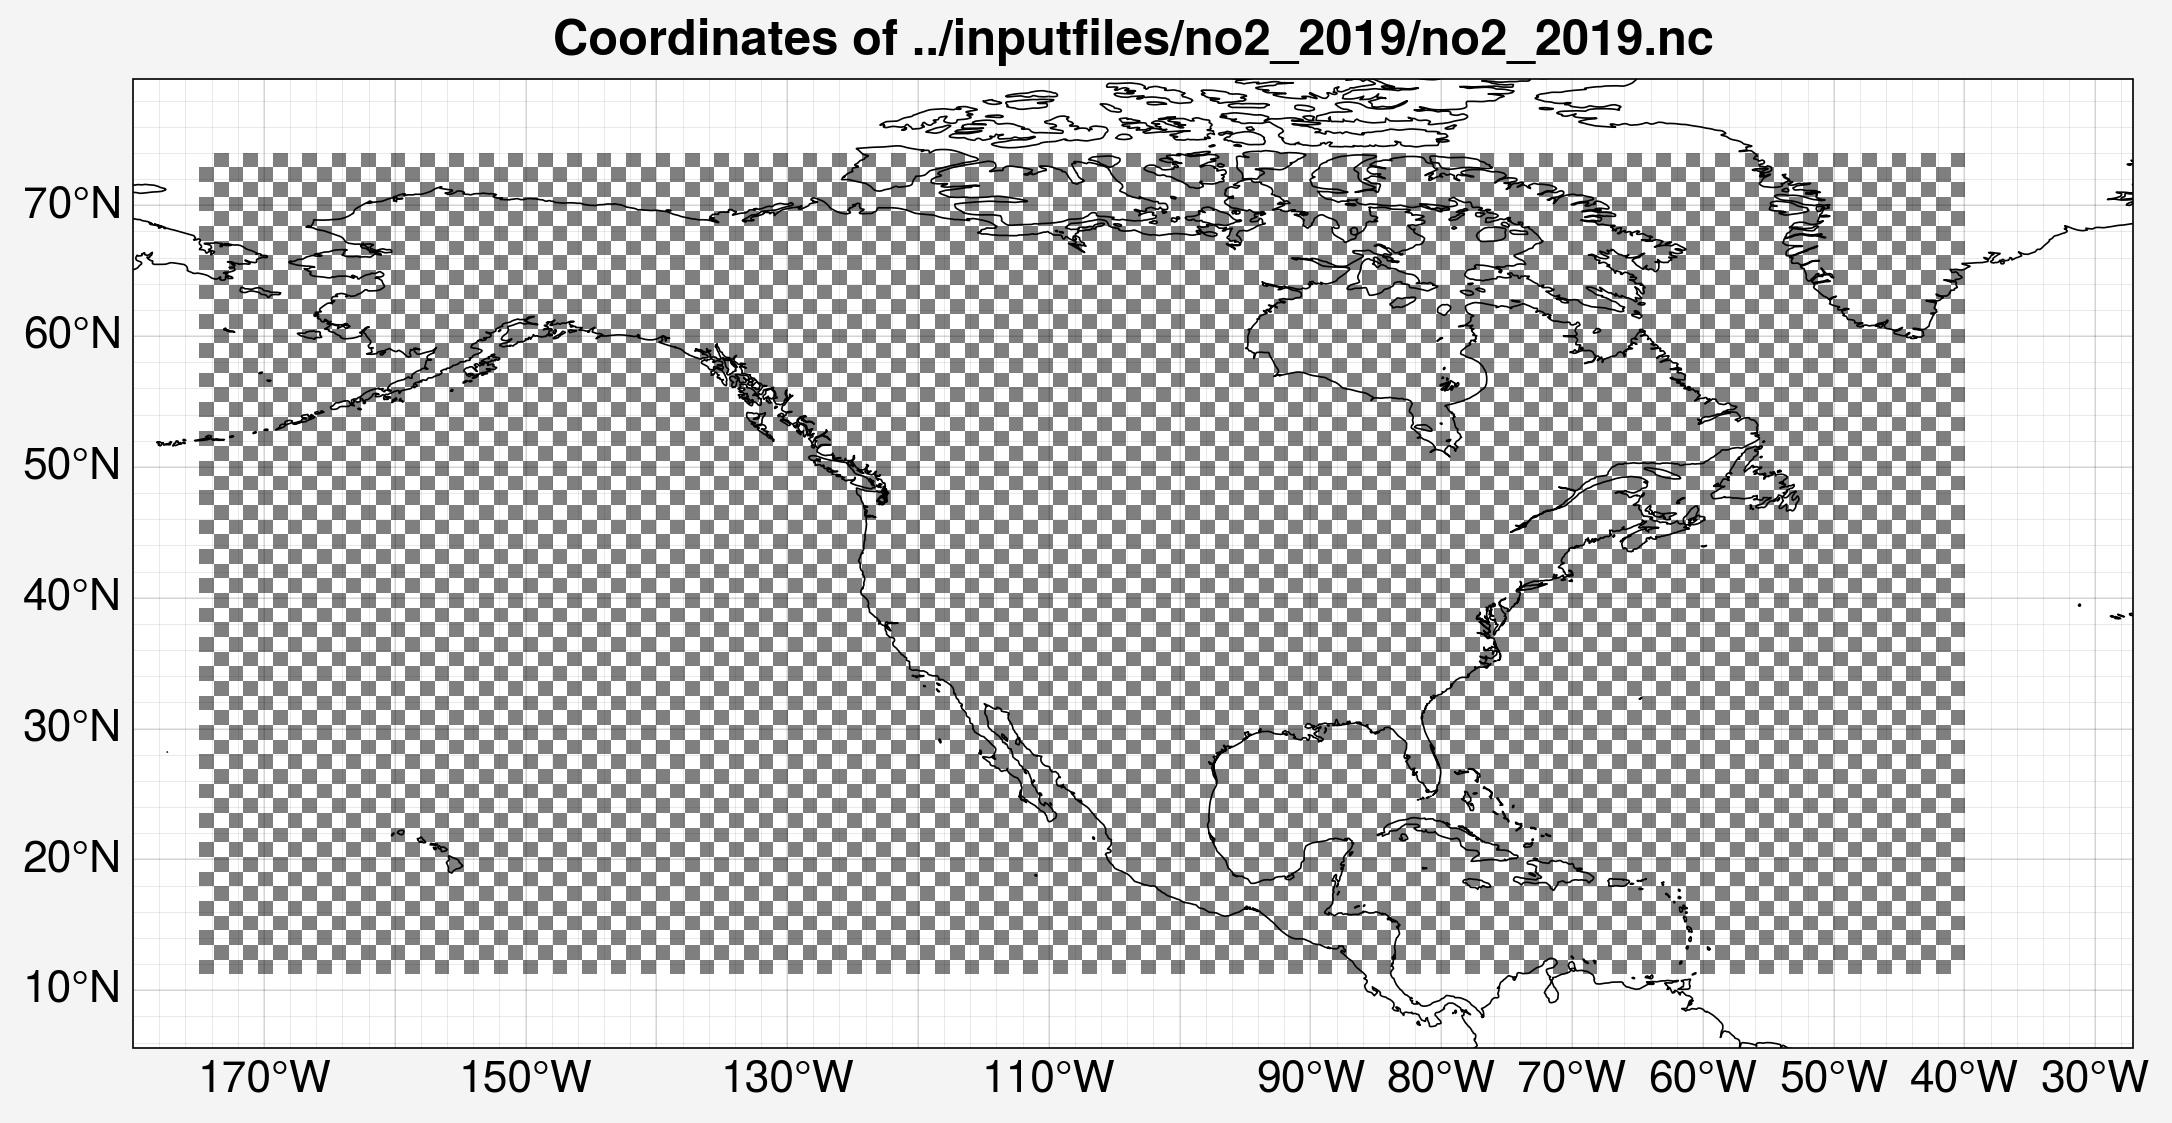

In [7]:
from unox.plotting import plot_lats_lons 

lats_lons_plot = plot_lats_lons(sample_dataset)

The next cell shows an example of plotting the contents of particular variables on a map. 
The specific variables (`var`) and date (`datetime`) will need to be selected such that they are within the given dataset.
This function also has an optional argument called `avg_over` which, if given, will plot the temporal average across the specified time interval to average over starting at the `datetime` date.
The `avg_over` interval is specified by a string in the format `XT` where `X` is an integer and `T` is the time unit, either `D` for days or `M` for months.

/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes i

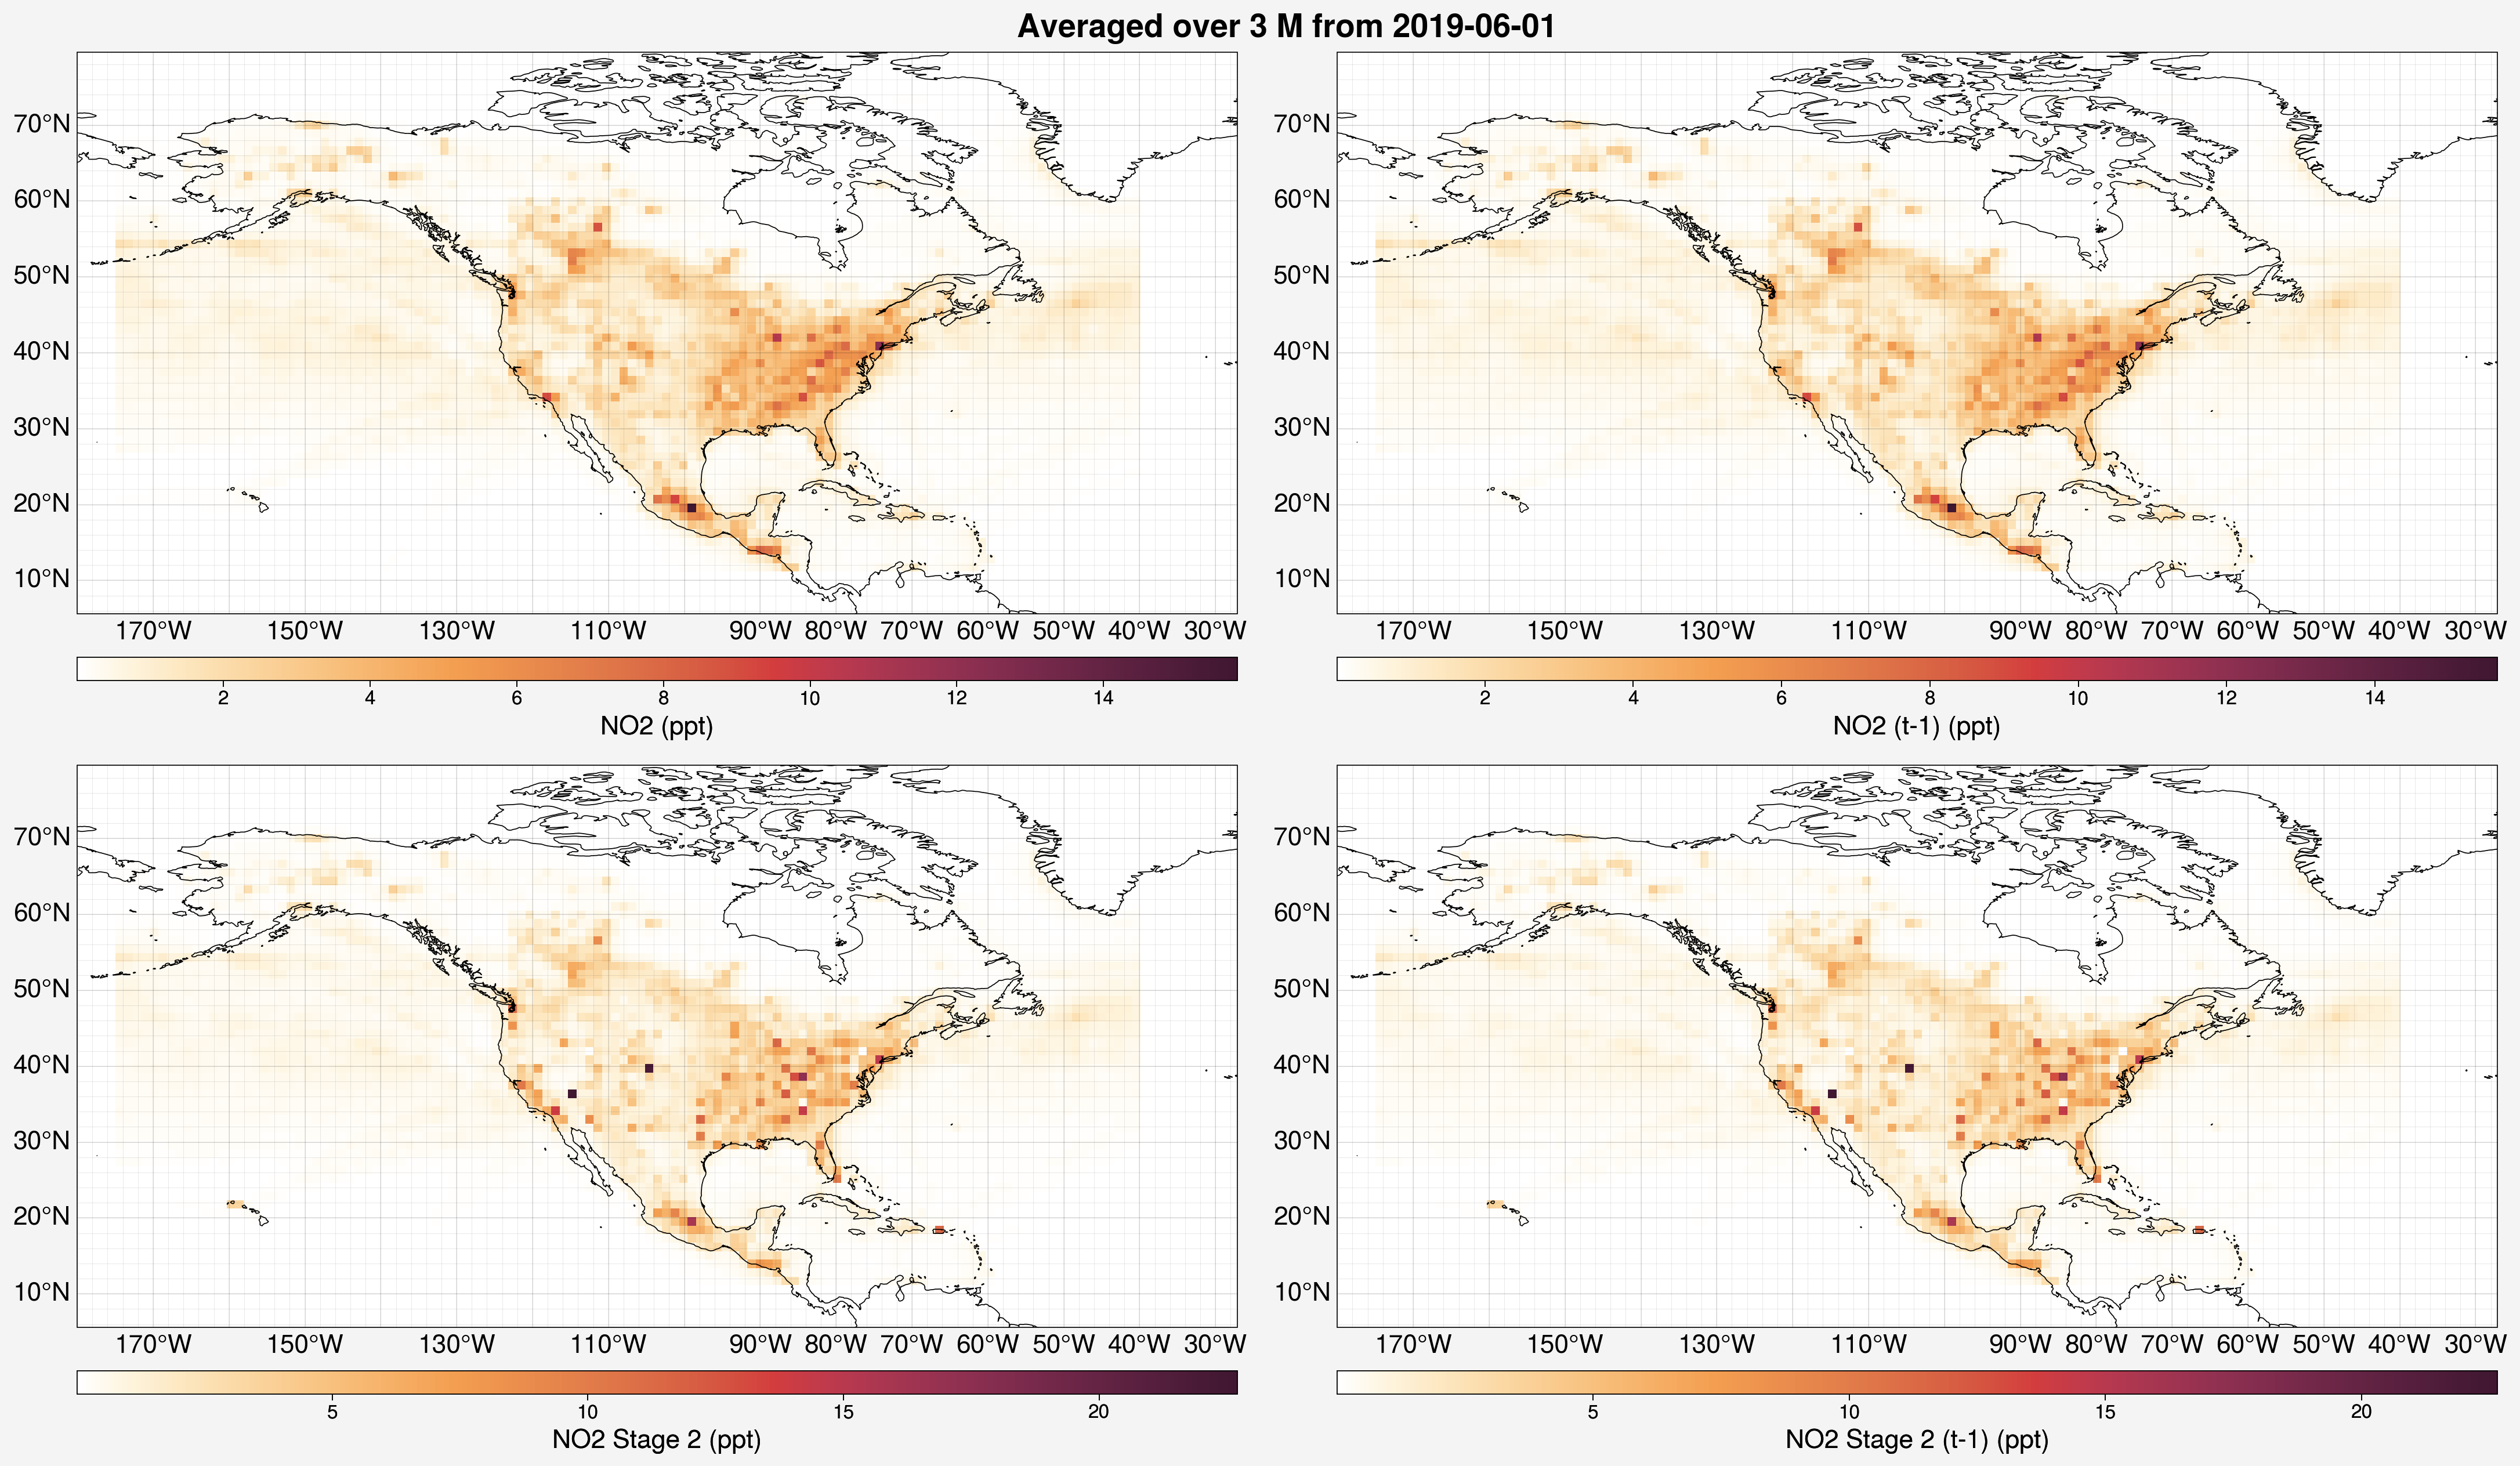

In [8]:
from unox.plotting import plot_var_maps

var_plots = plot_var_maps(
    '../inputfiles/no2_2019/no2_2019.nc',
    vars = ['no2', 'no2_tm1', 'no2_s2', 'no2_s2_tm1'],
    datetime='2019-06-01',
    avg_over='3M',
)

<a id='uarray_inspect'></a>
[back to top](#top)
### Inspecting `uarray` objects

The code base contains an object class called `uarray`, which is defined in the `unox.HPC.data0.dataset` module. 
This class is meant to extend the functionality of `xarray` objects by adding custom attributes. 
Most of the analysis functions use `uarray` objects. 
The following arguments can be specified when creating a `uarray` object:
- `set_to_get`
    - The only required argument. This is the dataset to make into a `uarray` object.
    - This can either be an `xarray` object or a string specifying where the data is located.
- `is_input_set`
    - A boolean option whether the data to add to the `uarray` is an input file.
    - If `True`, then `set_to_get` can simply be a string of the name of the input file and the code will find it in the `inputfiles/` directory automatically.
- `is_predict`
    - A boolean option whether the data to add to the `uarray` is from a model output prediction.
    - If `True`, then `set_to_get` can simply be a string of the name of the model run and the code will find it in the `HPC_runs/` directory automatically.

Below is an example of making a `uarray` from an input file and inspecting the underlying `xarray` by calling the `.xr` attribute.

In [9]:
from unox.HPC.data0.dataset import uarray

input_u_arr = uarray('no2_2019', is_input_set=True)
input_u_arr.xr

<xarray.Dataset> Size: 254MB
Dimensions:     (time: 364, lat: 56, lon: 120, var: 1)
Coordinates:
  * lat         (lat) float32 224B 11.78 12.9 14.02 15.14 ... 71.21 72.34 73.46
  * lon         (lon) float32 480B -174.4 -173.2 -172.1 ... -42.75 -41.62 -40.5
  * time        (time) object 3kB 2019-01-02 00:00:00 ... 2019-12-31 00:00:00
Dimensions without coordinates: var
Data variables: (12/13)
    nox         (time, lat, lon, var) float64 20MB ...
    no2         (time, lat, lon) float64 20MB ...
    no2_s2      (time, lat, lon) float64 20MB ...
    no2_tm1     (time, lat, lon) float64 20MB ...
    no2_s2_tm1  (time, lat, lon) float64 20MB ...
    u10         (time, lat, lon) float64 20MB ...
    ...          ...
    blh         (time, lat, lon) float64 20MB ...
    sp          (time, lat, lon) float64 20MB ...
    skt         (time, lat, lon) float64 20MB ...
    t2m         (time, lat, lon) float64 20MB ...
    ssrd        (time, lat, lon) float64 20MB ...
    lsm         (time, lat, lon) float64 20MB ...
Attributes: (12/17)
    description:        Input data for the Unet model. Data for each year is ...
    y_var:              nox
    emiss_dir:          /data/high_res/emacdonald/unet/datafiles/t106
    emiss_pre:          nox_
    emiss_post:         _t106_US.nc
    nan_fill:           0
    ...                 ...
    x2_vars:            ['no2_s2', 'no2_s2_tm1', 'u10', 'v10', 'blh', 'sp', '...
    data_dir:           /data/high_res
    chemra_path:        emacdonald/unet/datafiles/TROPESS/TROPESS_reanalysis_...
    insitu_path:        US_EPA/NO2/daily_NO2/daily_42602_
    era5_path:          ERA5concatenated
    stages:             [1 2]

Below is an example of making a `uarray` from model predictions and inspecting the underlying `xarray` by calling the `.xr` attribute.

In [1]:
from unox.HPC.data0.dataset import uarray

predict_u_arr = uarray('write_docs1', is_predict=True)
predict_u_arr.xr

<xarray.Dataset> Size: 39MB
Dimensions:      (time: 728, lat: 56, lon: 120)
Coordinates:
  * time         (time) object 6kB 2019-01-02 00:00:00 ... 2020-12-31 00:00:00
  * lat          (lat) float32 224B 11.78 12.9 14.02 15.14 ... 71.21 72.34 73.46
  * lon          (lon) float32 480B -174.4 -173.2 -172.1 ... -42.75 -41.62 -40.5
Data variables:
    nox_pred     (time, lat, lon) float32 20MB ...
    nox_pred_s2  (time, lat, lon) float32 20MB ...

The `is_input_set` and `is_predict` keyword arguments can be passed to plotting functions to avoid needing to specify the exact file path to the data to plot.

/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


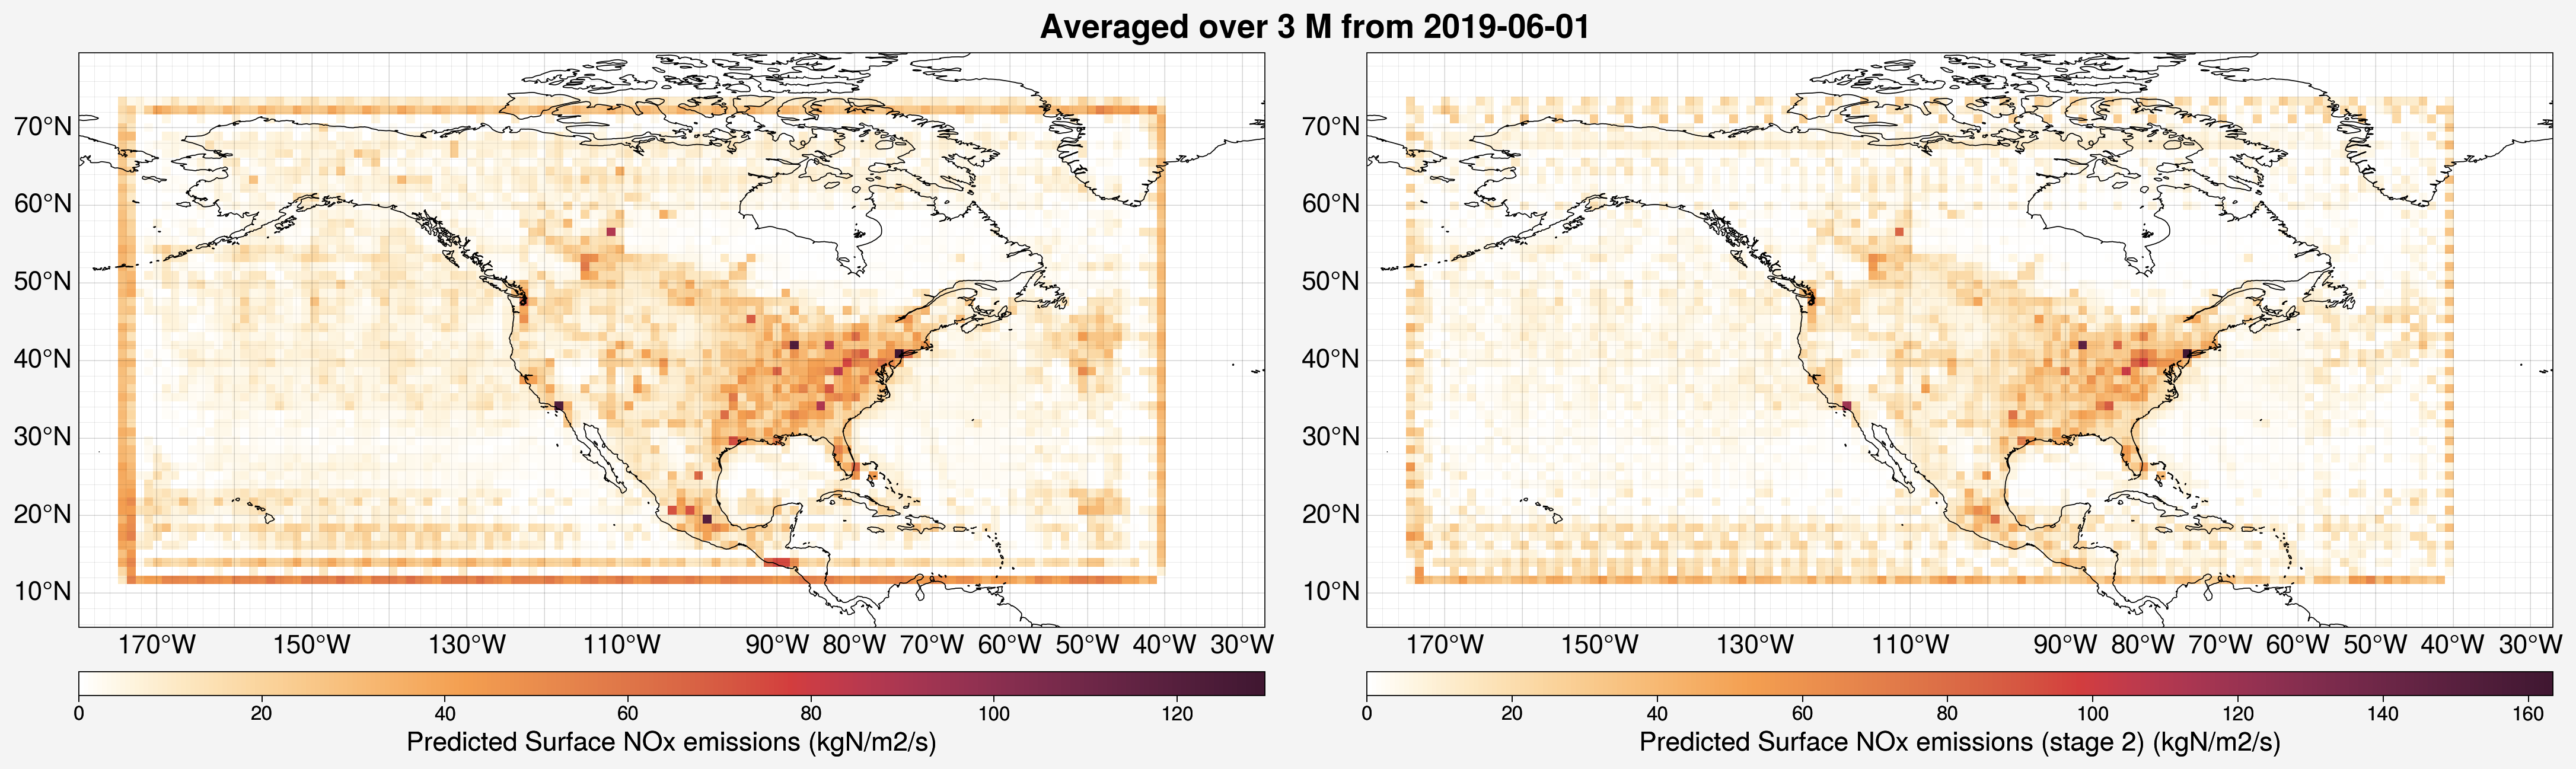

In [1]:
from unox.plotting import plot_var_maps

var_plots = plot_var_maps(
    'write_docs1',
    is_predict=True,
    vars = ['nox_pred', 'nox_pred_s2'],
    datetime='2019-06-01',
    avg_over='3M',
)

---
<a id='compare_inputs'></a>
[back to top](#top)
## Comparing inputs

If you are generating new input files and would like to compare them to previous iterations, the `plotting.compare_input_vars()` function might be useful. 
In this function, you can specify two arrays to compare to each other by specifying:
- `input_set`
    - The name of the input file to use.
- `year`
    - The year for which to make the comparison.
- `var`
    - The variable for which to make the comparison.

The function will let you know how many values differ between the two specified arrays and, if there are differences, it will make plots to give an idea of what the differences are.

This was designed to compare two different input files, however the examples below will make comparisons between parts of the same input file for demonstration. 
First, if the two arrays are exactly equal:

In [10]:
from unox.plotting import compare_input_vars

input_comparison = compare_input_vars(
    {
        'input_set': 'no2_2019',
        'year': 2019,
        'var': 'no2',
    },
    {
        'input_set': 'no2_2019',
        'year': 2019,
        'var': 'no2',
    }
)

Shape of no2 from no2_2019: (364, 56, 120)
Shape of no2 from no2_2019: (364, 56, 120)
Match found for no2_2019-2019-no2 vs no2_2019-2019-no2.


If the arrays do have differences, 6 plots will be made.
In these plots, the first array specified will be labeled as "A" and the second, "B".

Shape of no2 from no2_2019: (364, 56, 120)
Shape of no2_s2 from no2_2019: (364, 56, 120)
The input files differ more than the tolerance of 2e-05
Number of differences: 64603 / 2446080 ( 2.6410828754578755 % )


/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


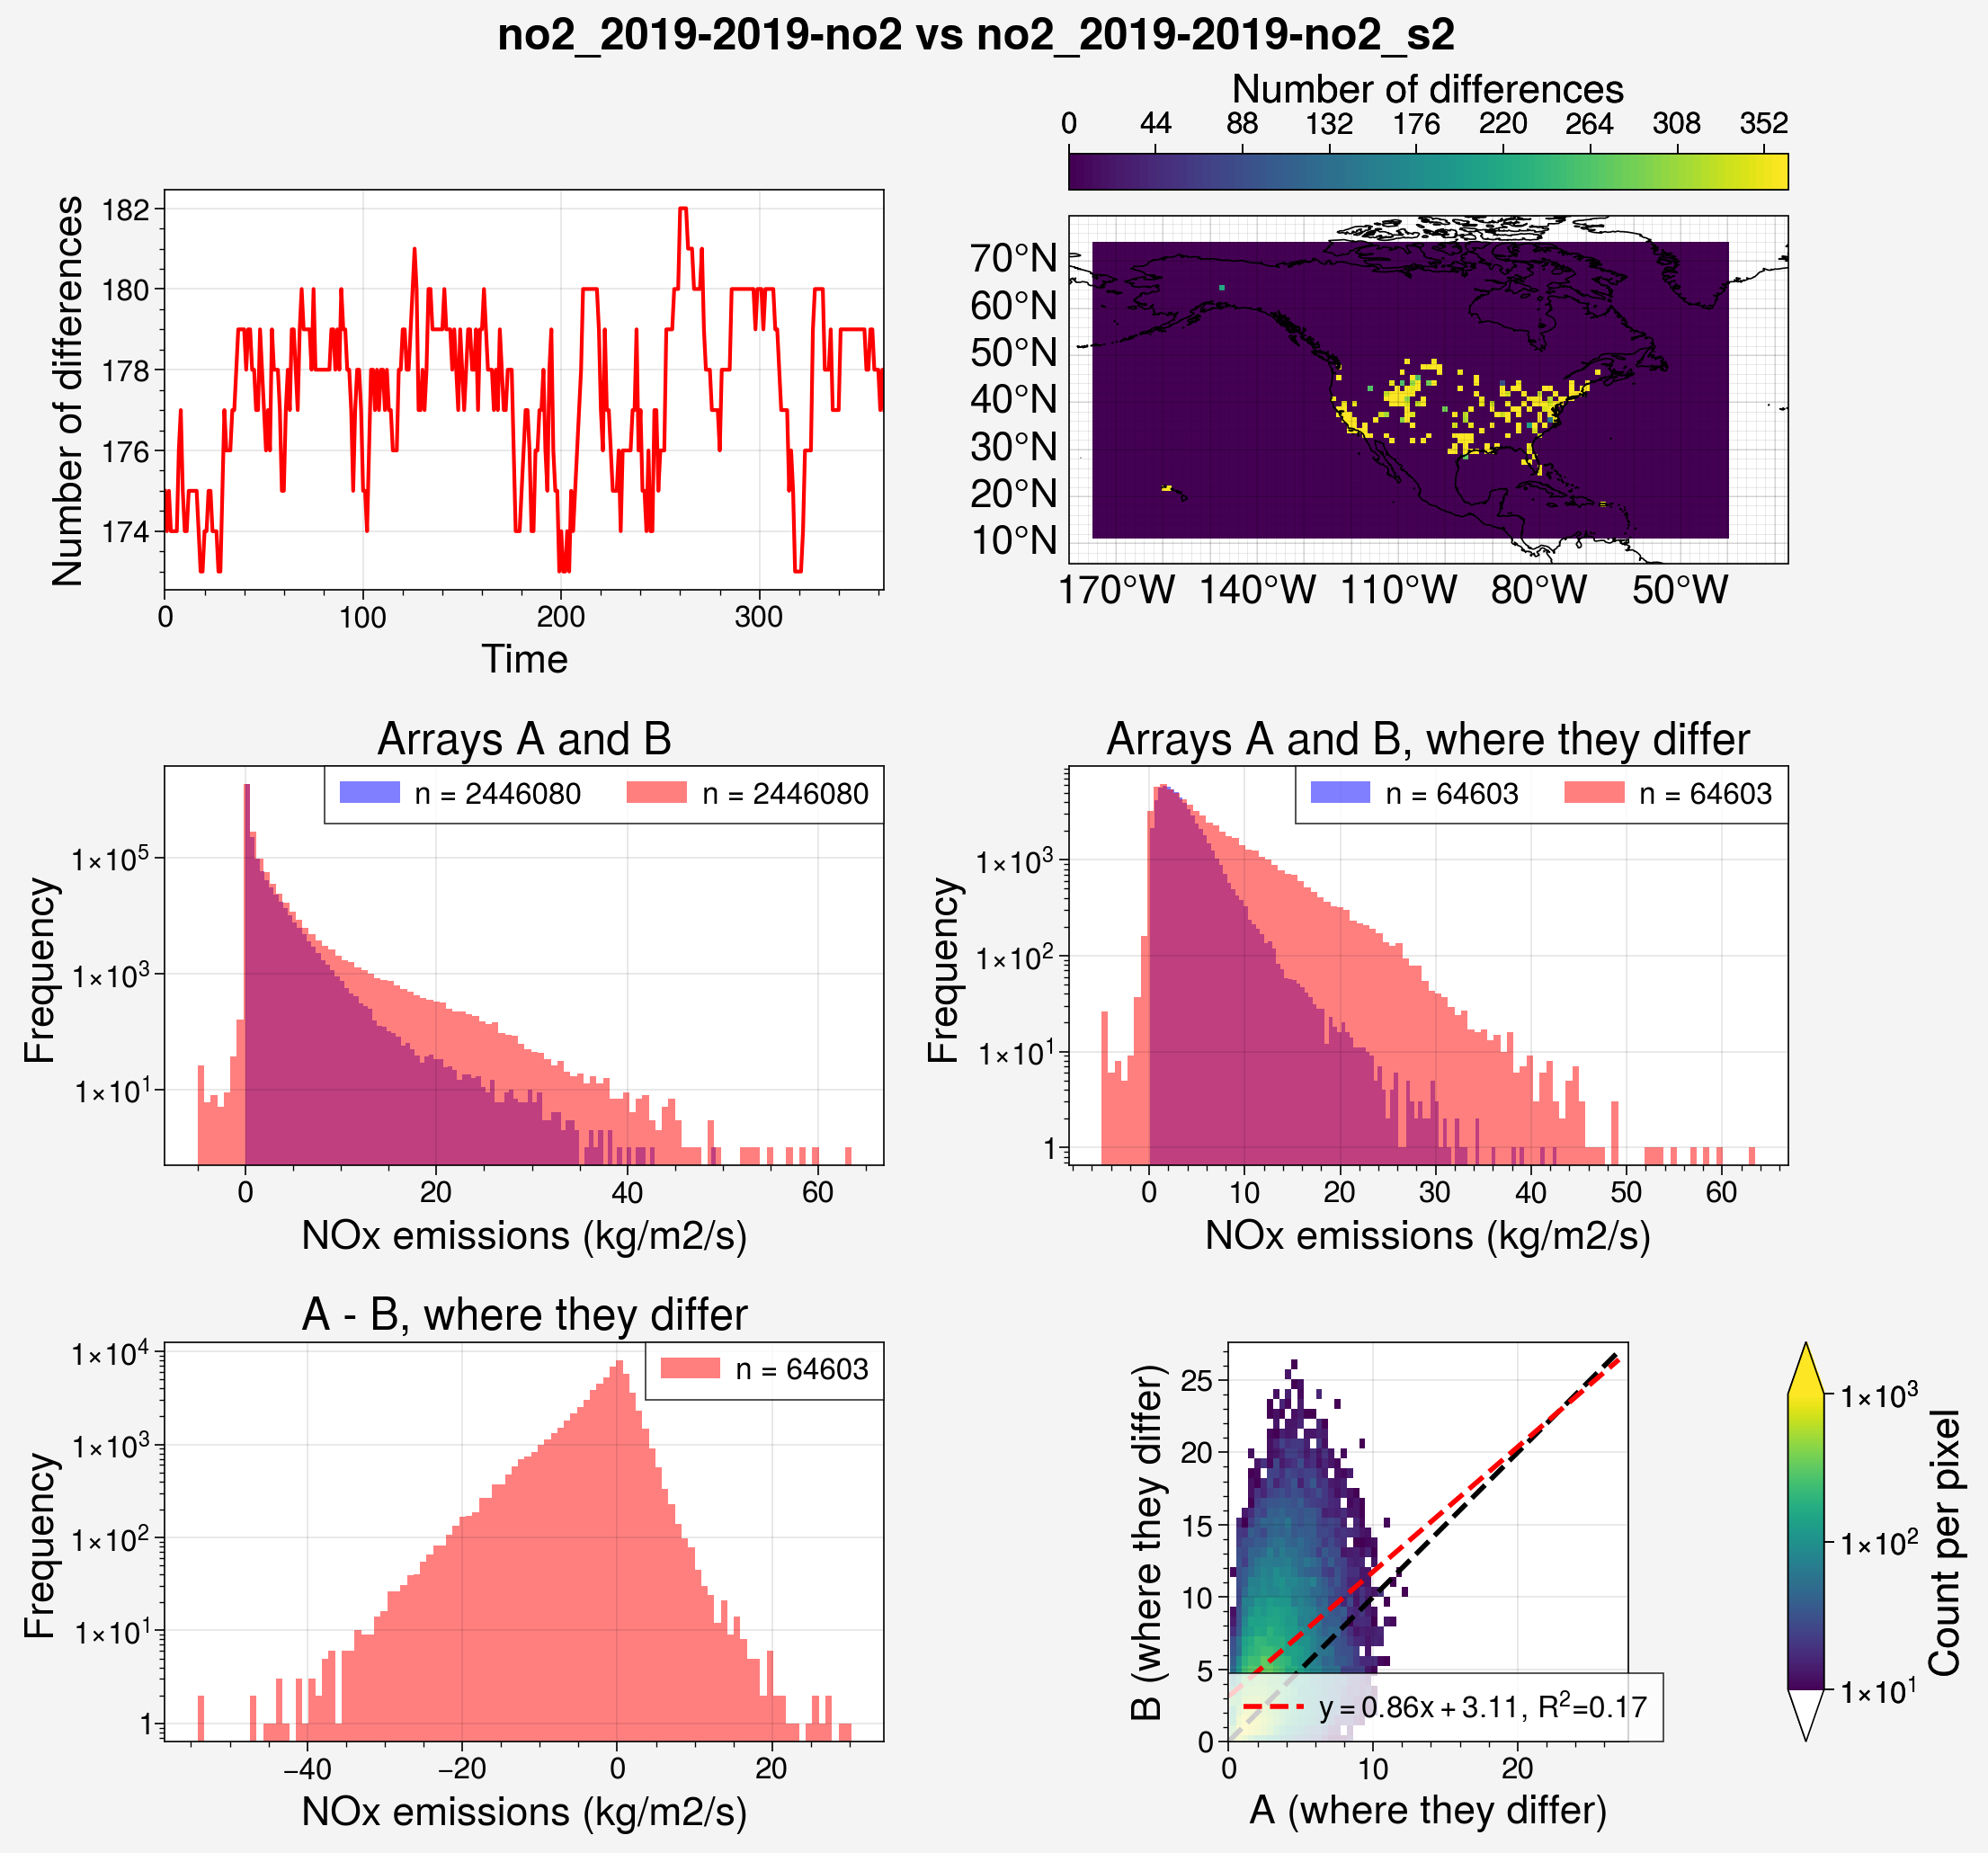

In [11]:
from unox.plotting import compare_input_vars

input_comparison = compare_input_vars(
    {
        'input_set': 'no2_2019',
        'year': 2019,
        'var': 'no2',
    },
    {
        'input_set': 'no2_2019',
        'year': 2019,
        'var': 'no2_s2',
    }
)

---
<a id='plotting_results'></a>
[back to top](#top)
## Plotting results

/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `m

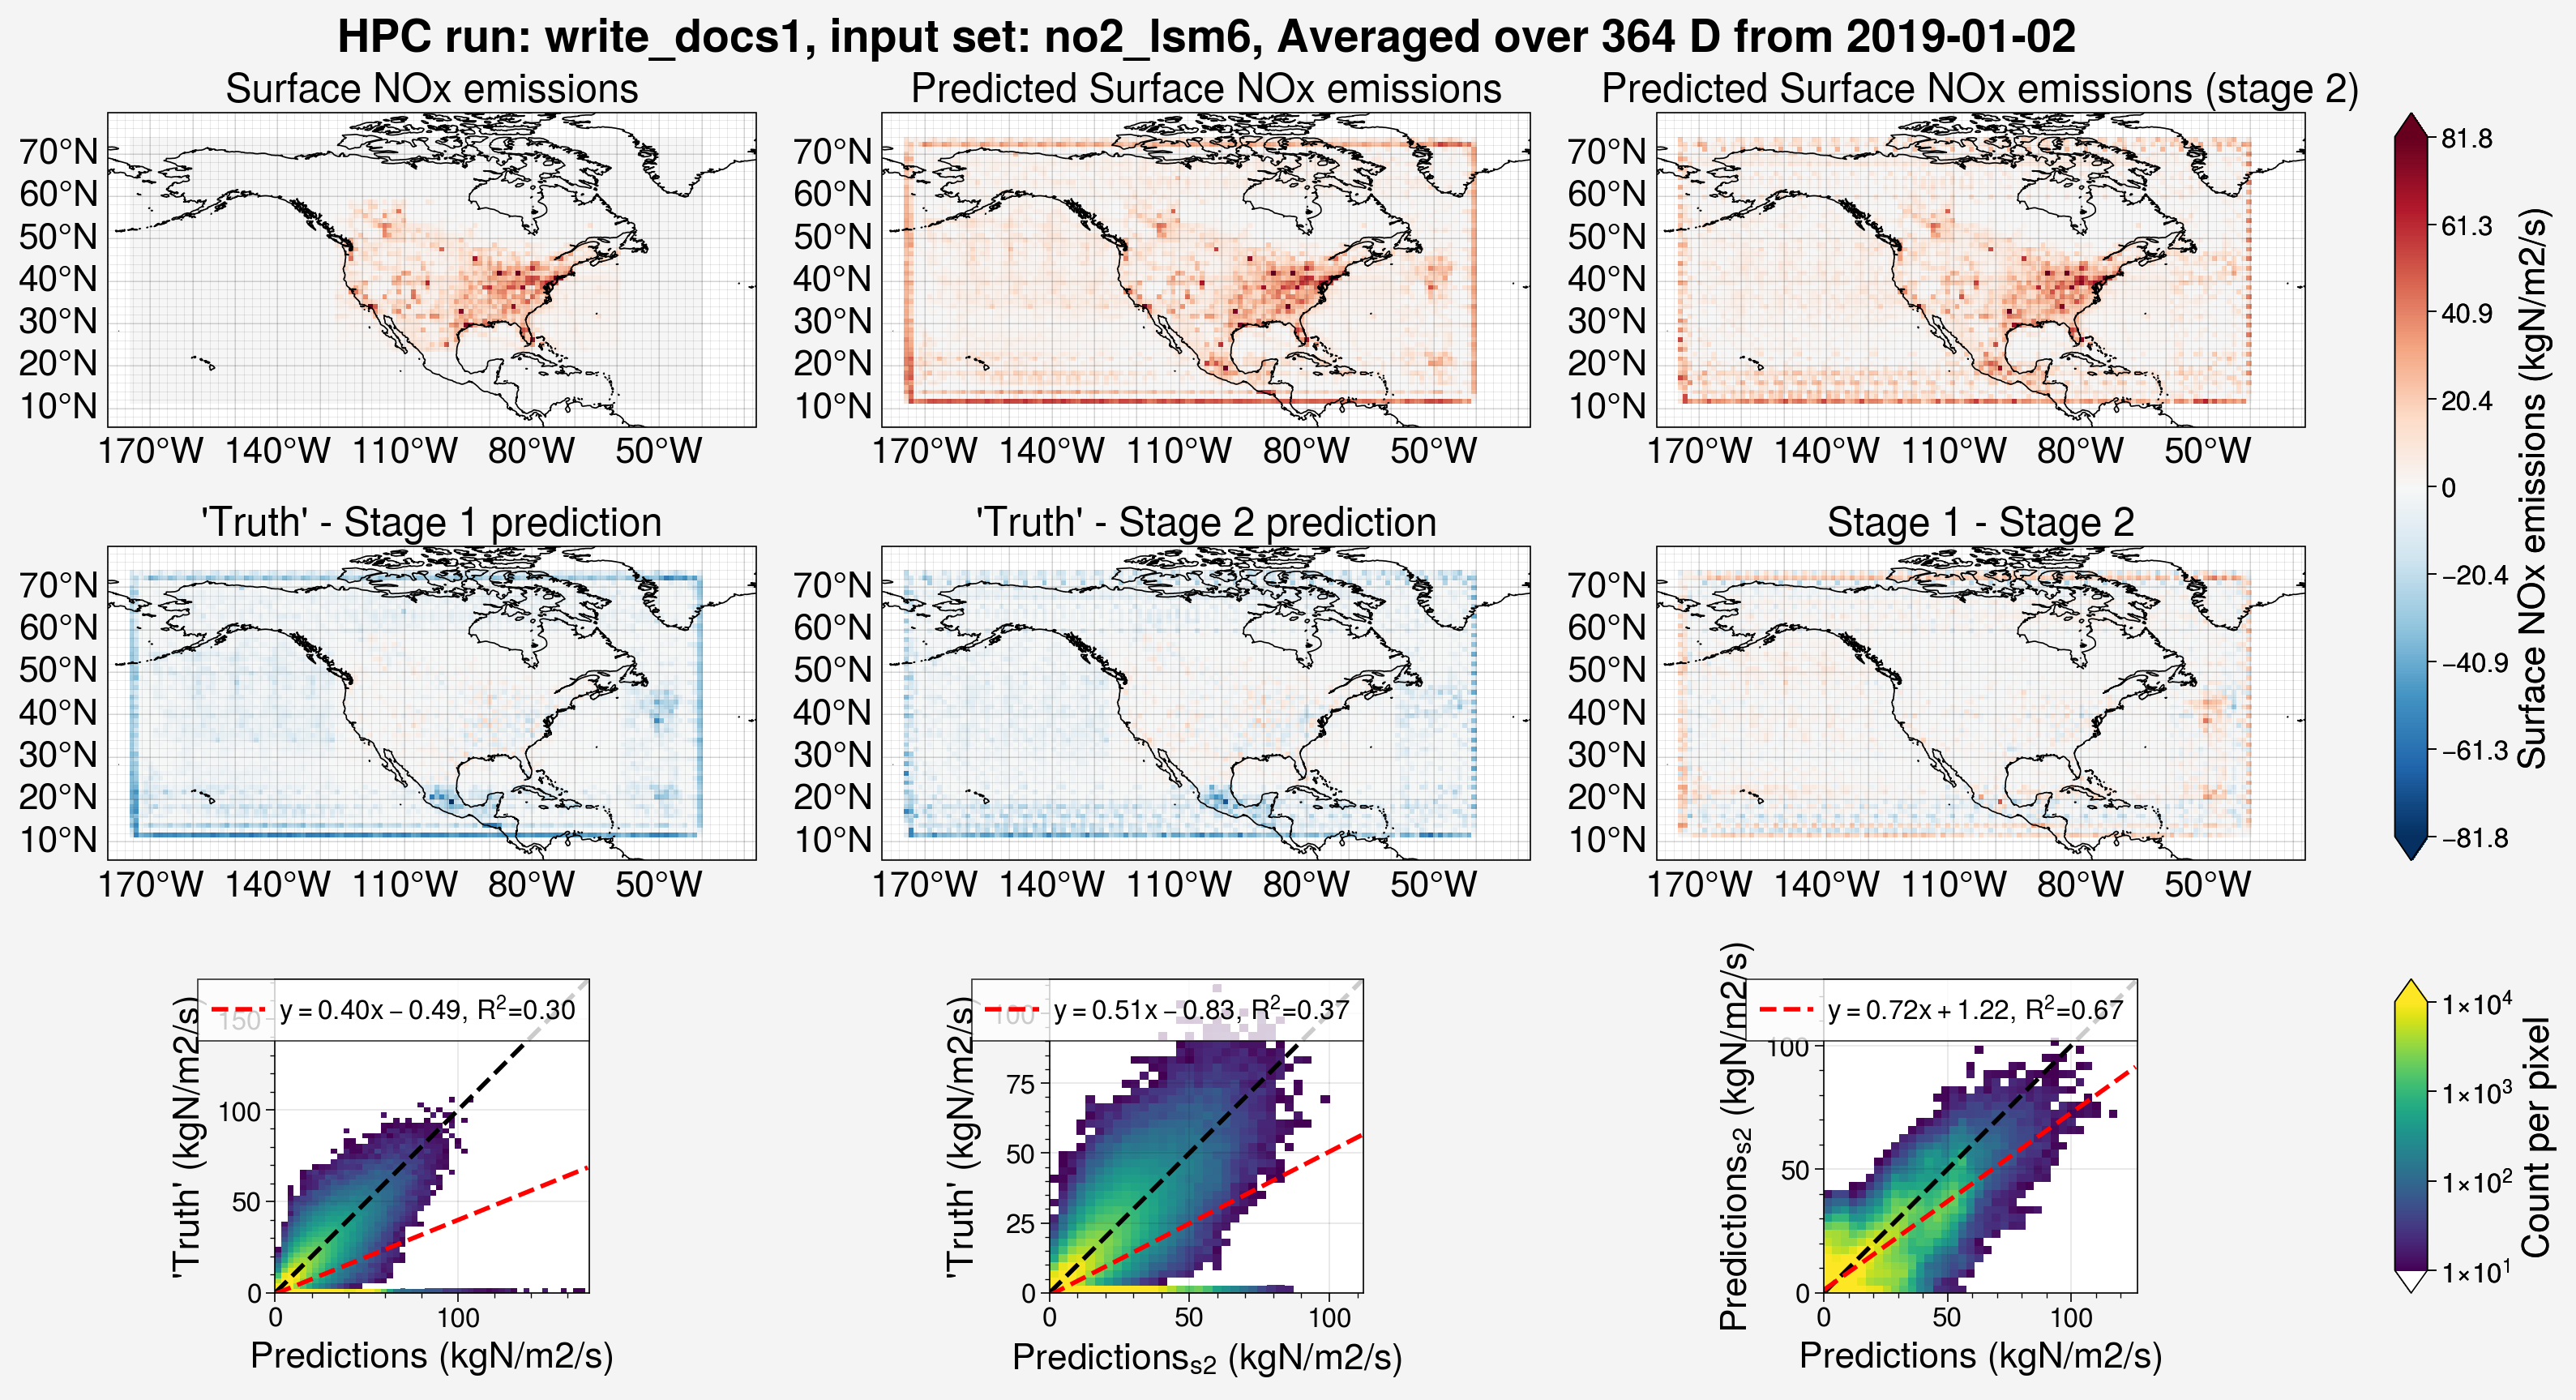

In [3]:
from unox.plotting import plot_comp_maps

this_plt = plot_comp_maps(
    HPC_run = 'write_docs1',
    year = 2019,
    datetime='2019-01-02T00:00:00',
    avg_over='364D',
    restrict_lat_lon_to=None,
    add_corr_plots=True,
)